#### Comparative Analysis for Public Health Decision-Making Using Machine Learning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
#### Data Preprocessing

In [4]:
# Read CSV file
df = pd.read_csv(r"C:/test.csv")


In [5]:
# Print DataFrame
print(df)

       Unnamed: 0                        Disease       County  Year     Sex  \
0            3364  Anaplasmosis and Ehrlichiosis        Marin  2001  Female   
1           47435                 Early Syphilis   San Benito  2009  Female   
2            8922            Botulism, Foodborne   San Benito  2001    Male   
3           85167                          Mumps  Santa Clara  2011    Male   
4           25591       Ciguatera Fish Poisoning       Lassen  2009  Female   
...           ...                            ...          ...   ...     ...   
18899       93322                    Psittacosis       Fresno  2007  Female   
18900       17063                    Brucellosis   Stanislaus  2006  Female   
18901       91141                  Plague, human         Lake  2003  Female   
18902       72278                  Leptospirosis      Alameda  2010    Male   
18903       81983                        Malaria         Yolo  2003  Female   

       Count  Population  Rate  CI.lower  CI.upper 

In [6]:
# Step 2: Filter rows for a specific disease
df = df[df['Disease'] == 'Measles']
print("\nFiltered for Measles:")
print(df.head())


Filtered for Measles:
     Unnamed: 0  Disease           County  Year     Sex  Count  Population  \
109       84115  Measles           Sonoma  2006    Male      0      231132   
120       83952  Measles           Shasta  2008  Female      0       89894   
180       83754  Measles  San Luis Obispo  2012    Male      0      138738   
198       84380  Measles         Tuolumne  2011  Female      0       25869   
245       82528  Measles            Glenn  2010  Female      0       13938   

     Rate  CI.lower  CI.upper  
109   0.0       0.0     1.596  
120   0.0       0.0     4.104  
180   0.0       0.0     2.659  
198   0.0       0.0    14.259  
245   0.0       0.0    26.463  


In [7]:
# Step 3: Convert 'Year' to datetime and set as index
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)
print("\nDateTime Indexed Data:")
print(df.head())



DateTime Indexed Data:
            Unnamed: 0  Disease           County     Sex  Count  Population  \
Year                                                                          
2006-01-01       84115  Measles           Sonoma    Male      0      231132   
2008-01-01       83952  Measles           Shasta  Female      0       89894   
2012-01-01       83754  Measles  San Luis Obispo    Male      0      138738   
2011-01-01       84380  Measles         Tuolumne  Female      0       25869   
2010-01-01       82528  Measles            Glenn  Female      0       13938   

            Rate  CI.lower  CI.upper  
Year                                  
2006-01-01   0.0       0.0     1.596  
2008-01-01   0.0       0.0     4.104  
2012-01-01   0.0       0.0     2.659  
2011-01-01   0.0       0.0    14.259  
2010-01-01   0.0       0.0    26.463  


In [8]:
# Step 4: Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0    0
Disease       0
County        0
Sex           0
Count         0
Population    0
Rate          0
CI.lower      0
CI.upper      0
dtype: int64


In [9]:
# Step 5: Sort by date
df = df.sort_index()

In [10]:
# Step 6: No missing values detected in Step 4, so no cleaning needed.


In [11]:
# Step 7: Check data types and summary stats
print("\nData Types:")
print(df.dtypes)



Data Types:
Unnamed: 0      int64
Disease        object
County         object
Sex            object
Count           int64
Population      int64
Rate          float64
CI.lower      float64
CI.upper      float64
dtype: object


In [12]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
         Unnamed: 0       Count    Population        Rate    CI.lower  \
count    360.000000  360.000000  3.600000e+02  360.000000  360.000000   
mean   83076.972222    0.355556  5.924312e+05    0.043517    0.006747   
std     2244.289767    2.503751  2.439500e+06    0.366562    0.074798   
min    61170.000000    0.000000  5.610000e+02    0.000000    0.000000   
25%    82669.000000    0.000000  2.253625e+04    0.000000    0.000000   
50%    83258.500000    0.000000  9.705100e+04    0.000000    0.000000   
75%    83900.500000    0.000000  3.507950e+05    0.000000    0.000000   
max    84513.000000   37.000000  1.915459e+07    5.842000    1.382000   

         CI.upper  
count  360.000000  
mean    23.735989  
std     78.054684  
min      0.048000  
25%      1.134000  
50%      3.899000  
75%     16.367500  
max    655.397000  


#### EDA

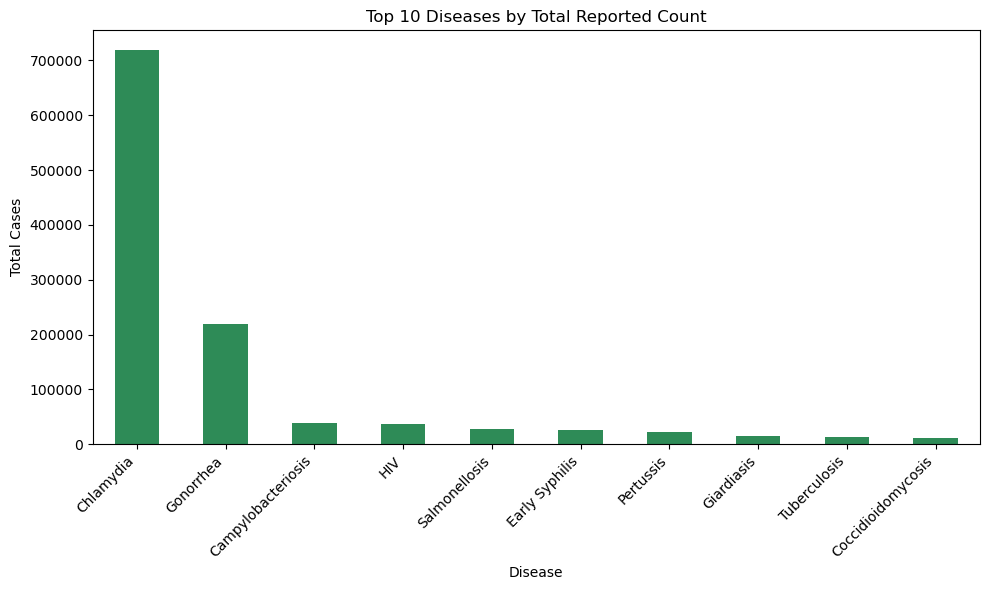

In [13]:
# Step 1: Load the CSV
df = pd.read_csv(r"C:/test.csv", header=0)

# Step 2: Fix duplicate columns – drop the first 'Disease' (the ID one)
df = df.loc[:, ~df.columns.duplicated()]  # removes duplicate column names

# Step 3: Rename the correct 'Disease' column
df.rename(columns={df.columns[0]: 'Disease_Code', df.columns[1]: 'Disease'}, inplace=True)

# Step 4: Ensure 'Count' is numeric
df['Count'] = pd.to_numeric(df['Count'], errors='coerce').fillna(0).astype(int)

# Step 5: Group by disease name and sum count
top_diseases = df.groupby('Disease')['Count'].sum().sort_values(ascending=False).head(10)

# Step 6: Plot
plt.figure(figsize=(10, 6))
top_diseases.plot(kind='bar', color='seagreen')
plt.title("Top 10 Diseases by Total Reported Count")
plt.ylabel("Total Cases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


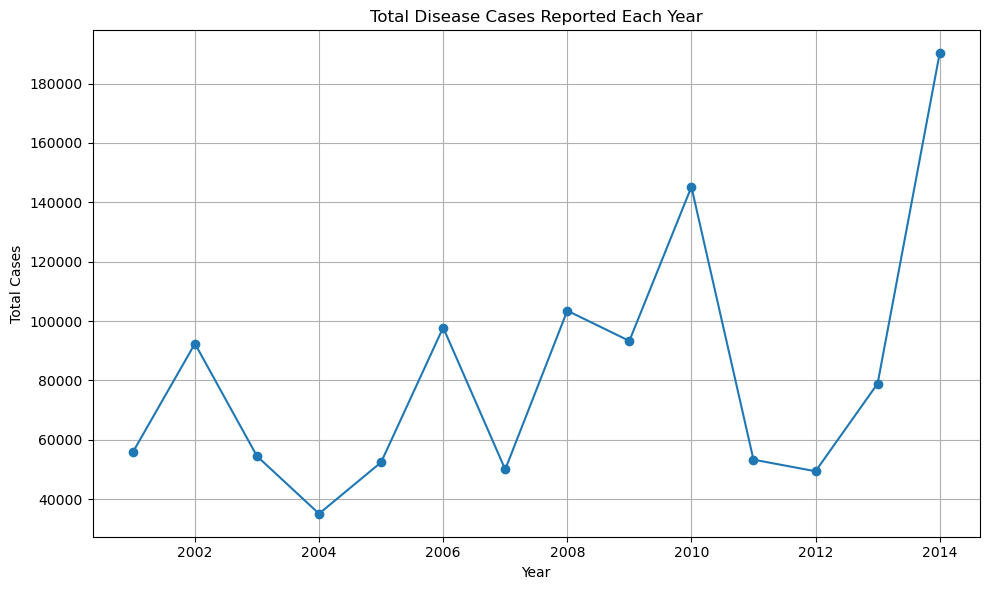

In [14]:
plt.figure(figsize=(10, 6))
yearly_cases = df.groupby("Year")["Count"].sum()
yearly_cases.plot(marker='o')
plt.title("Total Disease Cases Reported Each Year")
plt.ylabel("Total Cases")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

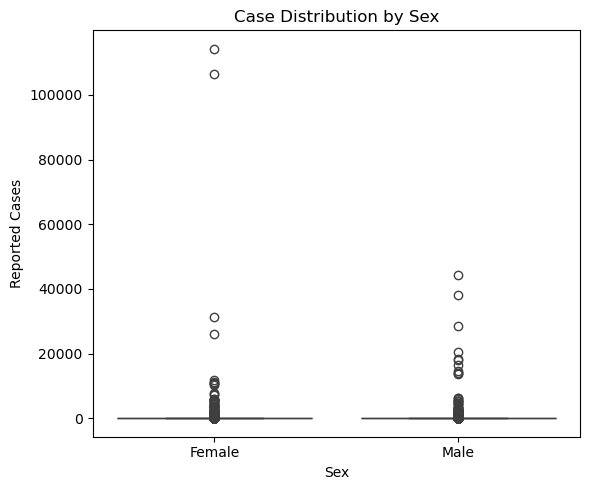

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="Sex", y="Count")
plt.title("Case Distribution by Sex")
plt.ylabel("Reported Cases")
plt.tight_layout()
plt.show()

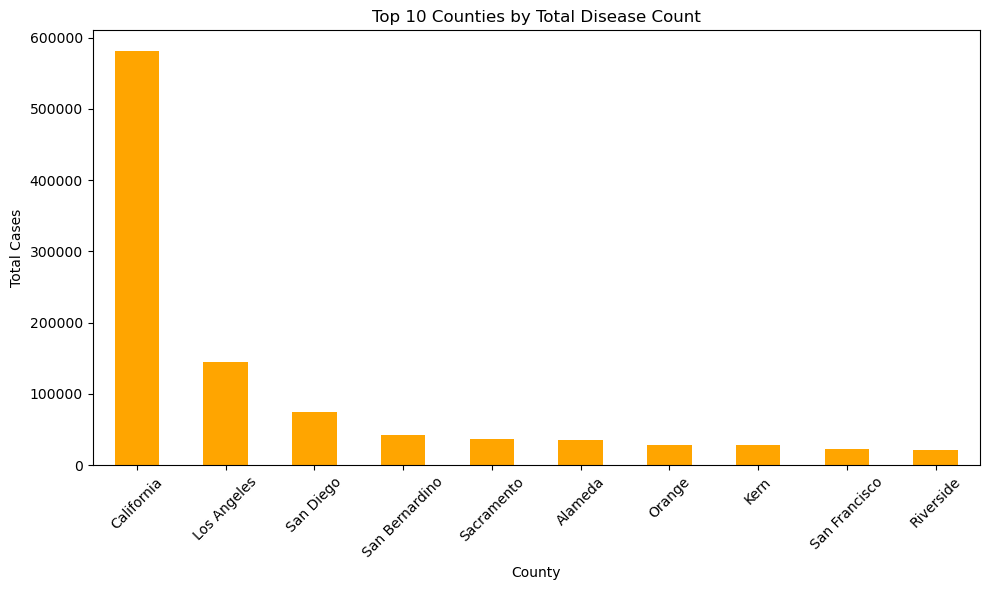

In [16]:
plt.figure(figsize=(10, 6))
top_counties = df.groupby("County")['Count'].sum().sort_values(ascending=False).head(10)
top_counties.plot(kind='bar', color='orange')
plt.title("Top 10 Counties by Total Disease Count")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

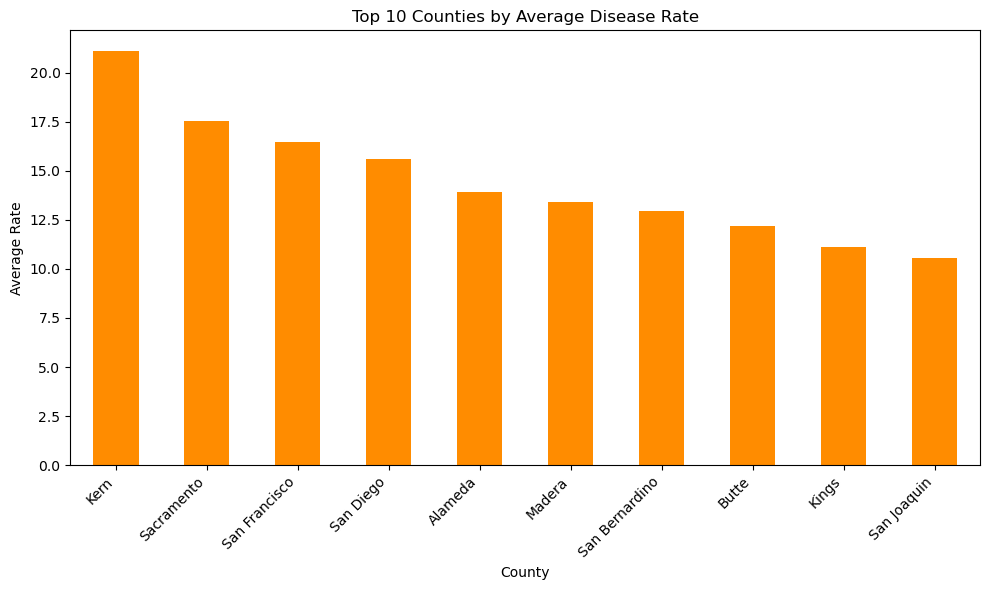

In [17]:
df = df.loc[:, ~df.columns.duplicated()]
df.rename(columns={df.columns[0]: 'Disease_Code'}, inplace=True)

# Group by County and compute mean rate
top_counties_rate = df.groupby('County')['Rate'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
top_counties_rate.plot(kind='bar', color='darkorange')
plt.title("Top 10 Counties by Average Disease Rate")
plt.ylabel("Average Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

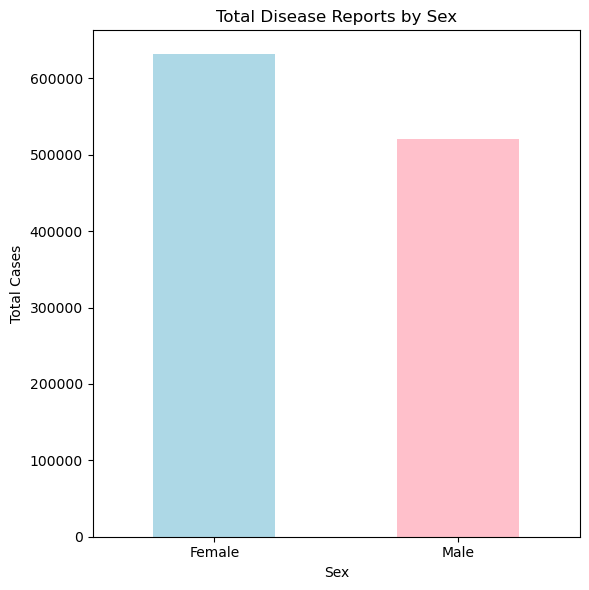

In [18]:
sex_grouped = df.groupby('Sex')['Count'].sum()

plt.figure(figsize=(6, 6))
sex_grouped.plot(kind='bar', color=['lightblue', 'pink'])
plt.title("Total Disease Reports by Sex")
plt.ylabel("Total Cases")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

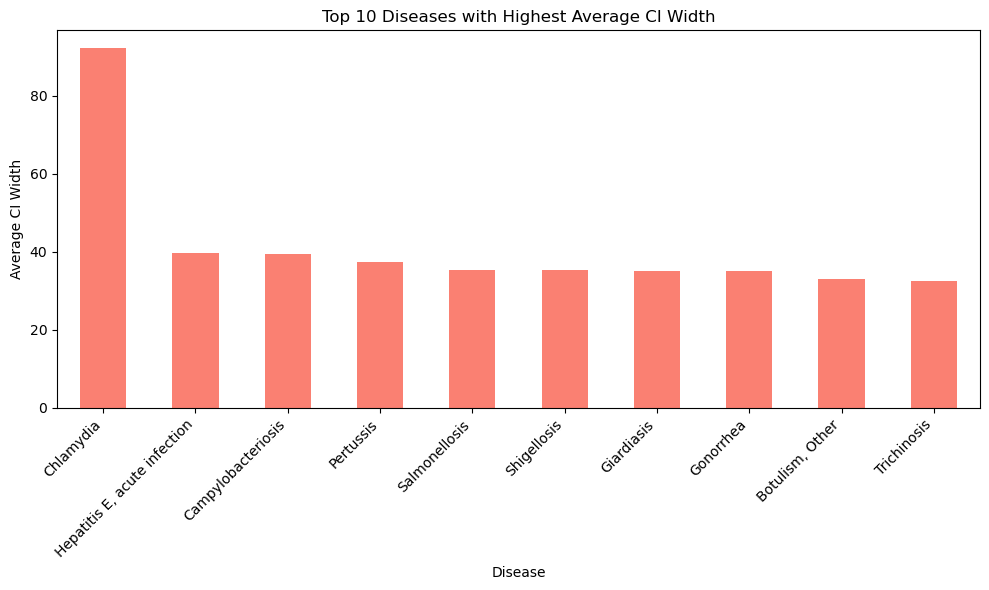

In [19]:
df['CI Width'] = df['CI.upper'] - df['CI.lower']

top_disease_ci = df.groupby('Disease')['CI Width'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_disease_ci.plot(kind='bar', color='salmon')
plt.title("Top 10 Diseases with Highest Average CI Width")
plt.ylabel("Average CI Width")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

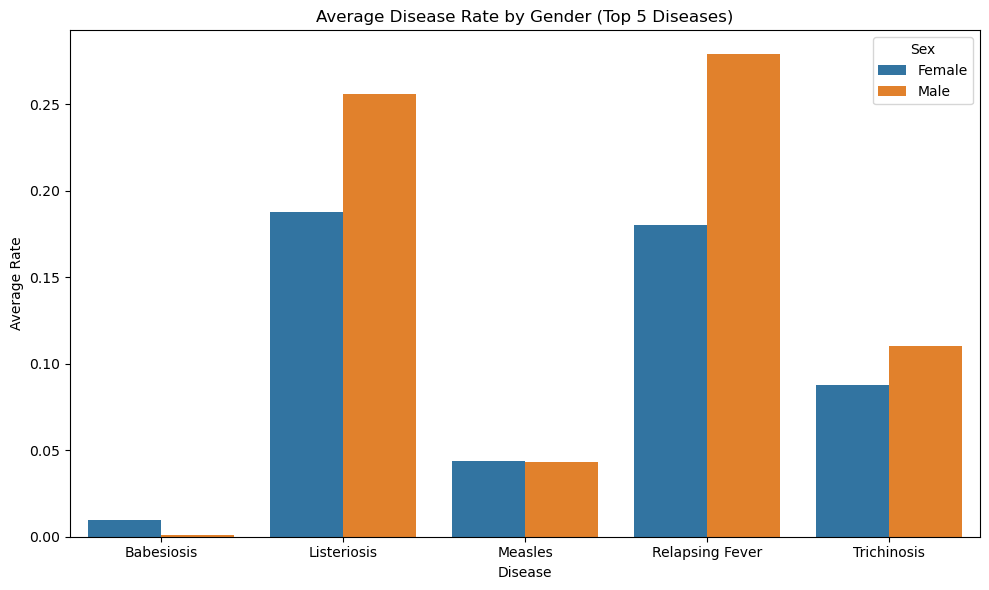

In [20]:
rate_by_disease_gender = df.groupby(['Disease', 'Sex'])['Rate'].mean().reset_index()

# Take top 5 diseases for clarity
top5 = df['Disease'].value_counts().head(5).index
rate_by_disease_gender = rate_by_disease_gender[rate_by_disease_gender['Disease'].isin(top5)]

plt.figure(figsize=(10, 6))
sns.barplot(data=rate_by_disease_gender, x='Disease', y='Rate', hue='Sex')
plt.title("Average Disease Rate by Gender (Top 5 Diseases)")
plt.ylabel("Average Rate")
plt.tight_layout()
plt.show()


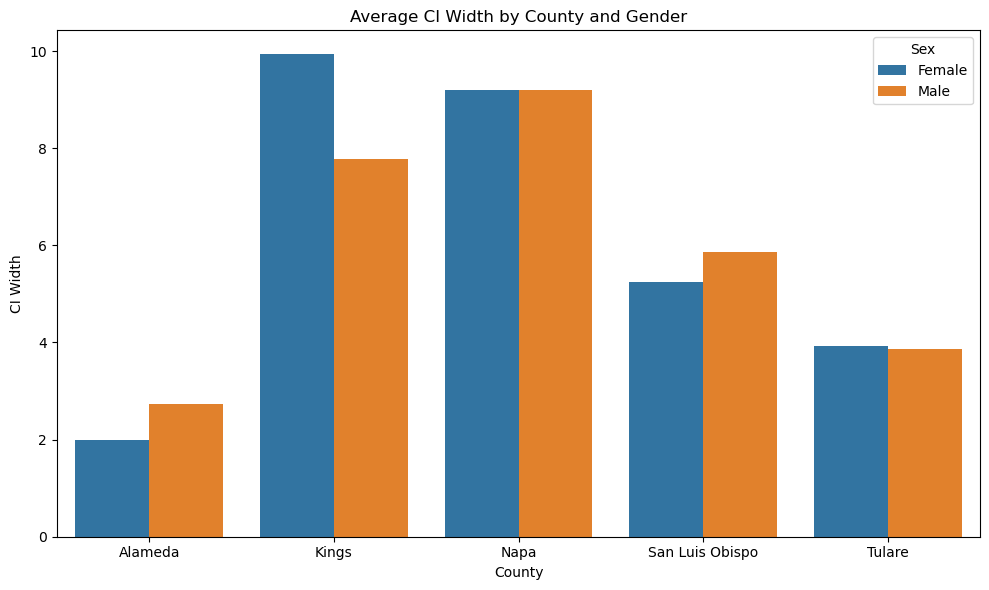

In [21]:
df['CI Width'] = df['CI.upper'] - df['CI.lower']
ci_gender = df.groupby(['County', 'Sex'])['CI Width'].mean().reset_index()

# Take top 5 counties by row count
top5_counties = df['County'].value_counts().head(5).index
ci_gender = ci_gender[ci_gender['County'].isin(top5_counties)]

plt.figure(figsize=(10, 6))
sns.barplot(data=ci_gender, x='County', y='CI Width', hue='Sex')
plt.title("Average CI Width by County and Gender")
plt.tight_layout()
plt.show()

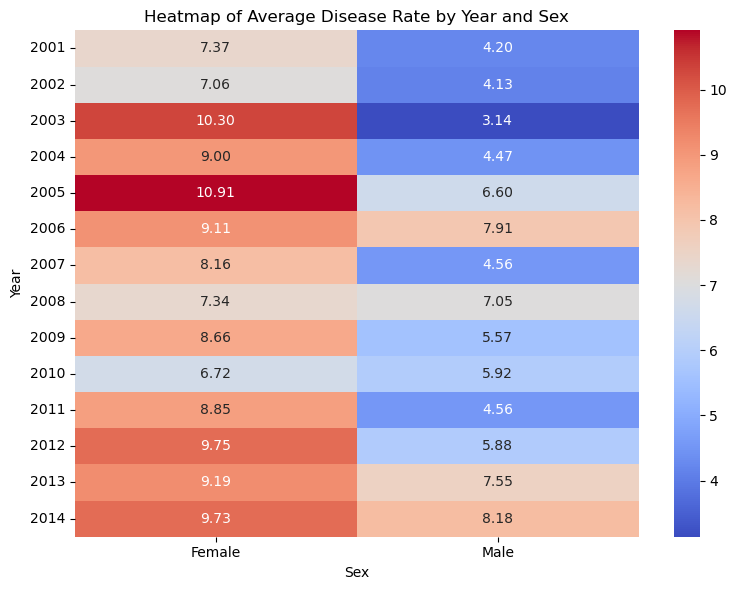

In [22]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Pivot table: average rate by Year and Sex
rate_heatmap = df.pivot_table(values='Rate', index='Year', columns='Sex', aggfunc='mean')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(rate_heatmap, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Heatmap of Average Disease Rate by Year and Sex")
plt.ylabel("Year")
plt.xlabel("Sex")
plt.tight_layout()
plt.show()

In [23]:
df = df.loc[:, ~df.columns.duplicated()]
df.rename(columns={df.columns[0]: 'Disease_Code'}, inplace=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

ts_df = df[df['Disease'] == 'Measles']

# Aggregate total count per year
ts = ts_df.groupby('Year')['Count'].sum().sort_index()

In [24]:
# ADF test
result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: 0.25778934266509923
p-value: 0.9753228121617499
Critical Value (1%): -4.473135048010974
Critical Value (5%): -3.28988060356653
Critical Value (10%): -2.7723823456790124


### ARIMA MODELLING

 ADF Test on Original Series
ADF Statistic: 0.25778934266509923
p-value: 0.9753228121617499
→ Series is NOT stationary. Applying differencing...


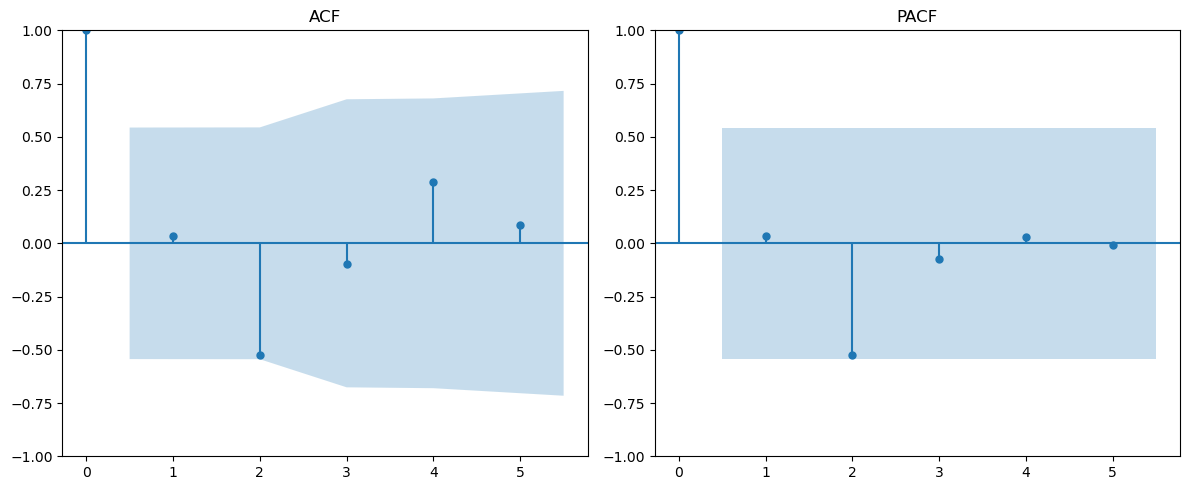

In [27]:
df = df.loc[:, ~df.columns.duplicated()]
df.rename(columns={df.columns[0]: 'Disease_Code'}, inplace=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Filter for one disease
target_disease = 'Measles'
ts_df = df[df['Disease'] == target_disease]
ts = ts_df.groupby('Year')[['Count', 'Population']].sum().reset_index().sort_values(by='Year')
ts.set_index('Year', inplace=True)

# Step 2: ADF Test
print(" ADF Test on Original Series")
adf_result = adfuller(ts['Count'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

if adf_result[1] > 0.05:
    print("→ Series is NOT stationary. Applying differencing...")
    ts['Count_diff'] = ts['Count'].diff()
    ts.dropna(inplace=True)
    d = 1
    diff_series = ts['Count_diff']
else:
    print("→ Series is already stationary.")
    ts['Count_diff'] = ts['Count']
    d = 0
    diff_series = ts['Count']

# Step 3: Dynamic ACF/PACF lags
max_lags = min(len(diff_series) // 2 - 1, 10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(diff_series, ax=plt.gca(), lags=max_lags)
plt.title('ACF')

plt.subplot(1, 2, 2)
plot_pacf(diff_series, ax=plt.gca(), lags=max_lags, method='ywm')
plt.title('PACF')
plt.tight_layout()
plt.show()

In [28]:
# --- Step 4: Chronological Train/Test Split (year-based) ---
# Ensure a proper time index for statsmodels
ts = ts.sort_index()
ts.index = pd.PeriodIndex(ts.index, freq='Y')

y = ts['Count']  # target series (use d from your ADF result)

# Year-based split (consistent with the report)
train_y = y[y.index.year <= 2012]
test_y  = y[y.index.year >= 2013]

print("Train years:", train_y.index.min(), "→", train_y.index.max())
print("Test  years:", test_y.index.min(),  "→", test_y.index.max())

# --- OPTIONAL: Log-transform to stabilize variance ---
eps = 1e-6
train_y_log = np.log(train_y + eps)
test_y_log  = np.log(test_y  + eps)

# --- Step 5: Fit ARIMA on TRAIN only ---
from statsmodels.tsa.arima.model import ARIMA

p, q = 1, 1  # adjust based on ACF/PACF
model = ARIMA(train_y, order=(p, d, q))
model_fit = model.fit()

print("\nARIMA Summary (trained on 2002–2012)")
print(model_fit.summary())

# --- Step 6: Forecast exactly the TEST horizon (2013–2014) ---
fc = model_fit.forecast(steps=len(test_y))

# --- Step 7: Evaluate on TEST only ---
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_y, fc))
mae  = mean_absolute_error(test_y, fc)
print(f"\nARIMA Test RMSE: {rmse:.3f}")
print(f"ARIMA Test MAE : {mae:.3f}")


Train years: 2002 → 2012
Test  years: 2013 → 2014

ARIMA Summary (trained on 2002–2012)
                               SARIMAX Results                                
Dep. Variable:                  Count   No. Observations:                   11
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -33.472
Date:                Wed, 27 Aug 2025   AIC                             72.943
Time:                        13:28:11   BIC                             73.851
Sample:                    12-31-2002   HQIC                            71.948
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1528      0.388      0.394      0.694      -0.608       0.914
ma.L1          0.9998    596.572      0.002

C:\Intel\New folder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Intel\New folder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [29]:
# --- Step 5b: ARIMAX with Exogenous Variable (Population) ---

# 1) Exogenous aligned with the same index
exog_all = ts[['Population']]  # already has PeriodIndex('Y')

# 2) Split exogenous by the same years
train_exog = exog_all.loc[train_y.index]
test_exog  = exog_all.loc[test_y.index]

# 3) Choose whether to use log or not
use_log = False   # set True if you decided to use the log-transform above

from statsmodels.tsa.arima.model import ARIMA

if use_log:
    # Fit on log-scale
    model_ex = ARIMA(train_y_log, order=(p, d, q), exog=train_exog)
    model_ex_fit = model_ex.fit()

    # Forecast on test horizon with exog
    fc_log_ex = model_ex_fit.forecast(steps=len(test_y), exog=test_exog)
    fc_ex = np.exp(fc_log_ex) - eps  # invert log
else:
    # Fit on original scale
    model_ex = ARIMA(train_y, order=(p, d, q), exog=train_exog)
    model_ex_fit = model_ex.fit()

    # Forecast on test horizon with exog
    fc_ex = model_ex_fit.forecast(steps=len(test_y), exog=test_exog)

print("\nARIMAX Summary (trained on 2002–2012 with Population)")
print(model_ex_fit.summary())

# 4) Evaluate on TEST only
rmse_ex = np.sqrt(mean_squared_error(test_y, fc_ex))
mae_ex  = mean_absolute_error(test_y, fc_ex)
print(f"ARIMAX Test RMSE: {rmse_ex:.3f}")
print(f"ARIMAX Test MAE : {mae_ex:.3f}")



ARIMAX Summary (trained on 2002–2012 with Population)
                               SARIMAX Results                                
Dep. Variable:                  Count   No. Observations:                   11
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -38.276
Date:                Wed, 27 Aug 2025   AIC                             84.553
Time:                        13:28:11   BIC                             85.763
Sample:                    12-31-2002   HQIC                            83.225
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Population   2.58e-07   2.26e-07      1.140      0.254   -1.86e-07    7.02e-07
ar.L1               0      0.264          0      1.000      -0.517       0.5

C:\Intel\New folder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Intel\New folder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Intel\New folder\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
print("\n AIC/BIC Comparison")
print(f"ARIMA  → AIC: {model_fit.aic:.2f}, BIC: {model_fit.bic:.2f}")
print(f"ARIMAX → AIC: {model_ex_fit.aic:.2f}, BIC: {model_ex_fit.bic:.2f}")


 AIC/BIC Comparison
ARIMA  → AIC: 72.94, BIC: 73.85
ARIMAX → AIC: 84.55, BIC: 85.76


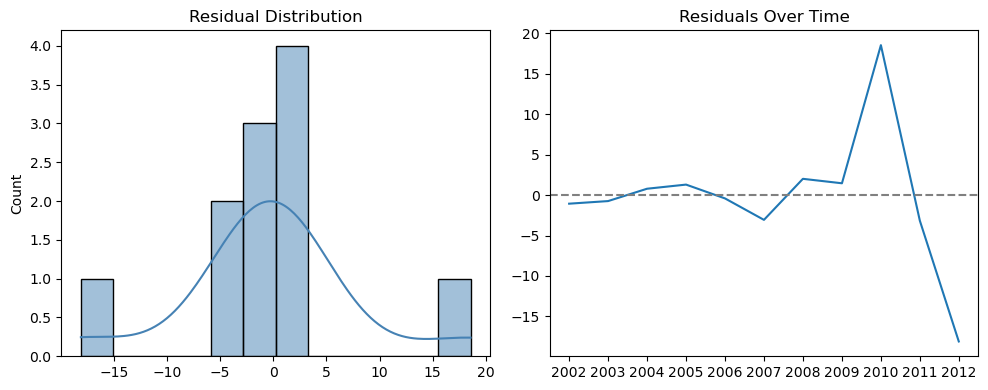

In [31]:
# --- Step 7: Residual Diagnostics ---
resid = pd.Series(model_ex_fit.resid, index=train_y.index)  # align with train
x = resid.index.to_timestamp()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(resid, kde=True, color='steelblue')
plt.title("Residual Distribution")

plt.subplot(1, 2, 2)
plt.plot(x, resid.values)
plt.axhline(0, color='gray', linestyle='--')
plt.title("Residuals Over Time")
plt.tight_layout()
plt.show()




In [32]:
lb_test = acorr_ljungbox(resid, lags=[min(10, len(resid)-2)], return_df=True)
print("\n Ljung-Box Test:")
print(lb_test)


 Ljung-Box Test:
   lb_stat  lb_pvalue
9  4.05766   0.907577


In [33]:
forecast_steps = 3
future_index = pd.period_range(start=ts.index[-1] + 1, periods=forecast_steps, freq='Y')

# Example: assume +1% growth in population per year
last_pop = ts['Population'].iloc[-1]
future_pop = [last_pop * (1.01 ** i) for i in range(1, forecast_steps + 1)]

exog_future = pd.DataFrame({'Population': future_pop}, index=future_index)

forecast = model_ex_fit.get_forecast(steps=forecast_steps, exog=exog_future)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Nice output
future_df = pd.DataFrame({
    'Predicted': pred_mean,
    'Lower_CI': conf_int.iloc[:, 0],
    'Upper_CI': conf_int.iloc[:, 1],
}, index=future_index)

print("\nARIMAX Future Forecasts")
print(future_df)



ARIMAX Future Forecasts
      Predicted  Lower_CI   Upper_CI
2015   4.074364 -13.98372  22.132448
2016        NaN       NaN        NaN
2017        NaN       NaN        NaN


In [34]:
forecast_steps = 3
future_index = pd.period_range(start=ts.index[-1] + 1, periods=forecast_steps, freq='Y')

# Example: assume +1% per year growth in Population
last_pop = ts['Population'].iloc[-1]
future_pop = [last_pop * (1.01 ** i) for i in range(1, forecast_steps + 1)]

exog_future = pd.DataFrame({'Population': future_pop}, index=future_index)

print("\nFuture exog used for forecast:")
print(exog_future)



Future exog used for forecast:
        Population
2015  2.456557e+07
2016  2.481122e+07
2017  2.505933e+07


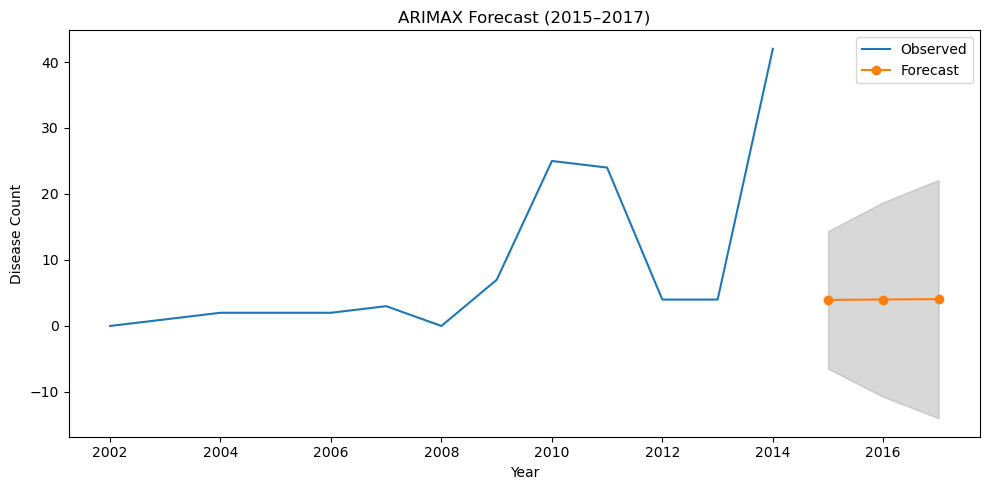


Forecasted Values:
2013    3.946987
2014    4.010359
2015    4.074364
Freq: Y-DEC, Name: predicted_mean, dtype: float64


In [36]:
plt.figure(figsize=(10, 5))

# Historical observed data
plt.plot(ts.index.to_timestamp(), ts['Count'], label='Observed')

# Forecasted values
plt.plot(future_index.to_timestamp(), pred_mean, label='Forecast', marker='o')

# Confidence interval shading
plt.fill_between(
    future_index.to_timestamp(),
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='gray', alpha=0.3
)

plt.title("ARIMAX Forecast (2015–2017)")
plt.xlabel("Year")
plt.ylabel("Disease Count")
plt.legend()
plt.tight_layout()
plt.show()

print("\nForecasted Values:")
print(pred_mean)


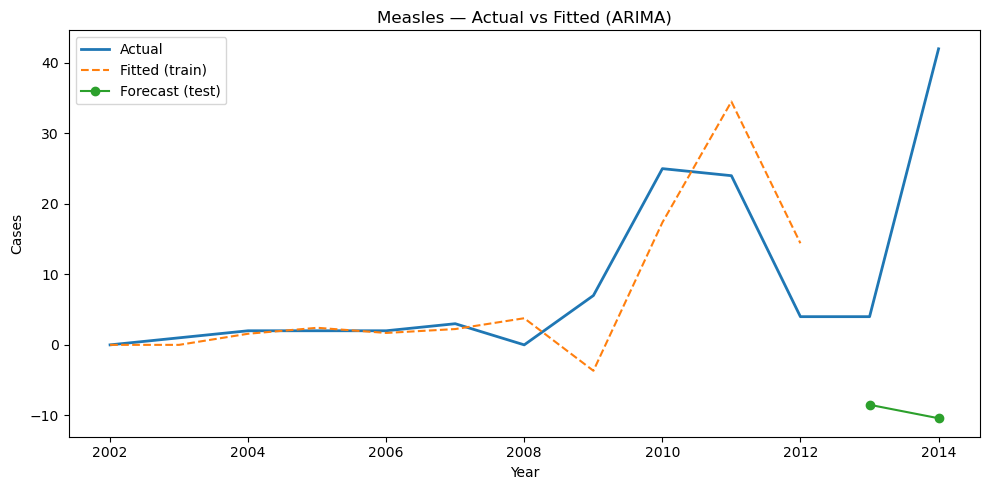

In [37]:
# --- Actual vs Fitted (TRAIN) + Forecast (TEST) ---

# Convert indices to timestamps for plotting
ts_x   = ts.index.to_timestamp()
train_x = train_y.index.to_timestamp()
test_x  = test_y.index.to_timestamp()

plt.figure(figsize=(10, 5))

# Actual full series
plt.plot(ts_x, ts['Count'], label='Actual', linewidth=2)

# Fitted values (train period only)
plt.plot(train_x, model_fit.fittedvalues, label='Fitted (train)', linestyle='--')

# Optional: if you already computed test forecast 'fc'
try:
    plt.plot(test_x, fc, label='Forecast (test)', marker='o')
except NameError:
    pass  # skip if fc not computed yet

plt.title(f'{target_disease} — Actual vs Fitted (ARIMA)')
plt.xlabel("Year")
plt.ylabel("Cases")
plt.legend()
plt.tight_layout()
plt.show()


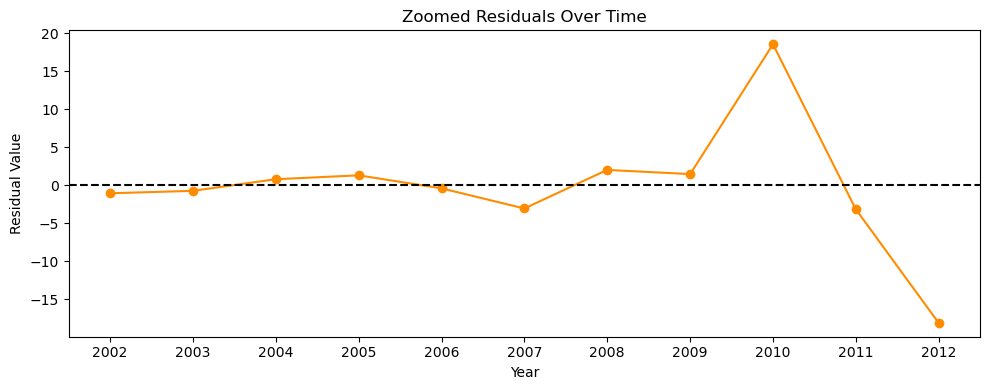

In [38]:
plt.figure(figsize=(10, 4))

# If resid is a Series aligned to train_y
plt.plot(resid.index.to_timestamp(), resid.values,
         marker='o', linestyle='-', color='darkorange')

plt.axhline(0, color='black', linestyle='--')
plt.title('Zoomed Residuals Over Time')
plt.xlabel("Year")
plt.ylabel("Residual Value")
plt.tight_layout()
plt.show()


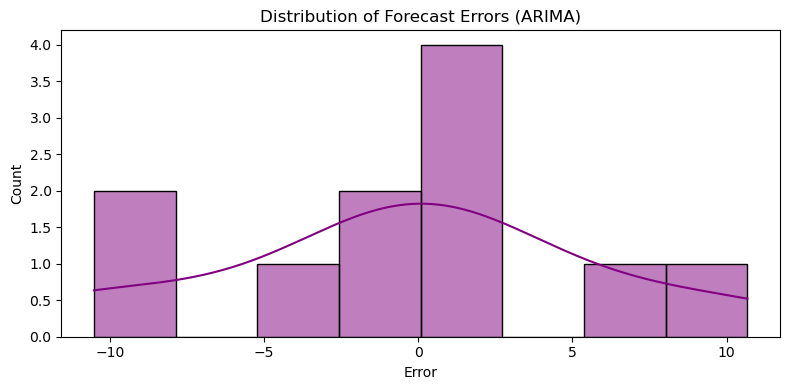

In [39]:
forecast_errors = ts['Count'] - model_fit.fittedvalues
plt.figure(figsize=(8, 4))
sns.histplot(forecast_errors, kde=True, color='purple')
plt.title("Distribution of Forecast Errors (ARIMA)")
plt.xlabel("Error")
plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Align predicted and actual values on the training period
train_y_true = train_y
train_y_pred = model_fit.fittedvalues

# Ensure both have matching index
train_y_true, train_y_pred = train_y_true.align(train_y_pred, join='inner')

# Calculate metrics
rmse = np.sqrt(mean_squared_error(train_y_true, train_y_pred))
mae  = mean_absolute_error(train_y_true, train_y_pred)

print("\nARIMA Evaluation Metrics (Training Set):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")



ARIMA Evaluation Metrics (Training Set):
RMSE: 6.09
MAE : 4.18


In [41]:
# --- Forecast for the test period (2013–2014) ---
fc_res = model_fit.get_forecast(steps=len(test_y))
fc = fc_res.predicted_mean
conf_int = fc_res.conf_int()

# --- Create a forecast table ---
forecast_index = test_y.index
forecast_df = pd.DataFrame({
    "Year": forecast_index,
    "Predicted": fc,
    "Lower_CI": conf_int.iloc[:, 0].values,
    "Upper_CI": conf_int.iloc[:, 1].values
})

print("\nForecast Table:")
print(forecast_df)

# --- Evaluate the forecast on the test set ---
rmse_test = np.sqrt(mean_squared_error(test_y, fc))
mae_test  = mean_absolute_error(test_y, fc)

print("\nARIMA Evaluation Metrics (Test Set):")
print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test MAE : {mae_test:.2f}")



Forecast Table:
      Year  Predicted   Lower_CI   Upper_CI
2013  2013  -8.501021 -20.824442   3.822400
2014  2014 -10.411222 -38.695172  17.872728

ARIMA Evaluation Metrics (Test Set):
Test RMSE: 38.10
Test MAE : 32.46


### XGBOOST

In [42]:
target_disease = 'Measles'
ts_df = df[df['Disease'] == target_disease]
ts = ts_df.groupby('Year')[['Count', 'Population']].sum().reset_index().sort_values(by='Year')


# Basic lags
for i in range(1, 7):
    ts[f'lag_{i}'] = ts['Count'].shift(i)

# Rolling averages
ts['rolling_mean_2'] = ts['Count'].rolling(window=2).mean()
ts['rolling_mean_3'] = ts['Count'].rolling(window=3).mean()

# Trend features
ts['Year_sq'] = ts['Year'] ** 2

# Lag differences
ts['lag_diff_1'] = ts['lag_1'] - ts['lag_2']

# Drop rows with NaN (due to lagging)
ts = ts.dropna().reset_index(drop=True)


features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6',
    'rolling_mean_2', 'rolling_mean_3',
    'Year', 'Year_sq', 'lag_diff_1',
    'Population'  # exogenous variable
]

# --- Chronological split (same as ARIMA/ARIMAX) ---
train = ts[ts['Year'] <= 2012]
test  = ts[ts['Year'] >= 2013]

X_train = train[features]
y_train = train['Count']
X_test = test[features]
y_test = test['Count']

In [71]:
# hyperparameter tuning(GridSearchCV)

In [44]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np
# --- time-series CV (expanding window) ---
tscv = TimeSeriesSplit(n_splits=3)  # small dataset → 3 is reasonable
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

# Use best model
model = grid.best_estimator_
print(" Best Parameters:", grid.best_params_)

 Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1}


# Predict AND Evaluate

In [45]:
# -----------------------------------
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n XGBoost Evaluation (Tuned):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


 XGBoost Evaluation (Tuned):
RMSE: 17.82
MAE: 13.18


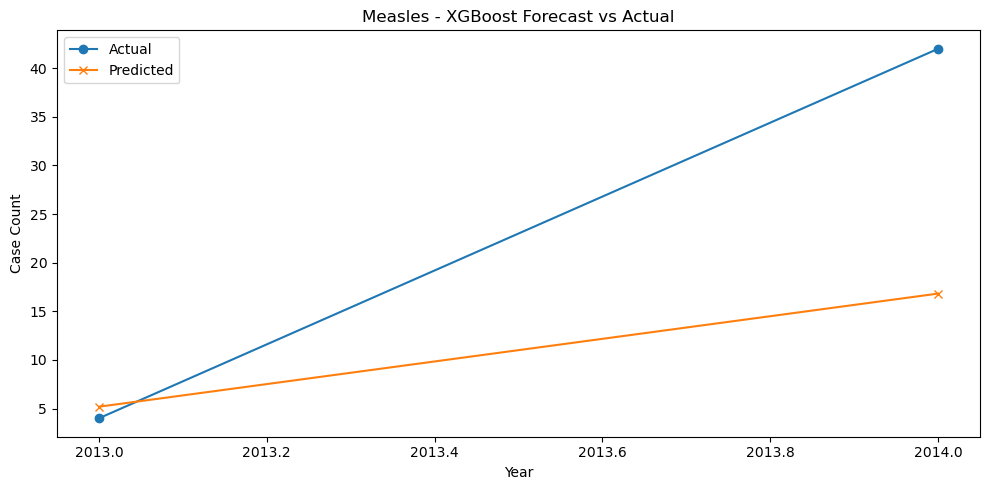

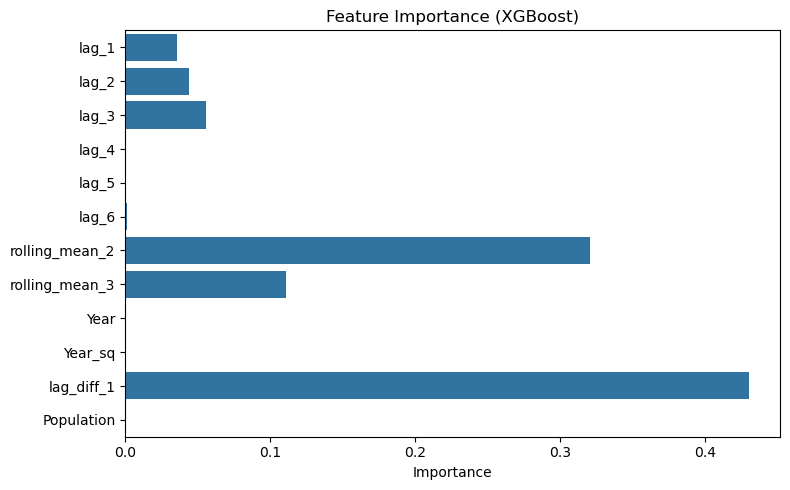

In [46]:
# Plot Predicted vs Actual

plt.figure(figsize=(10, 5))
plt.plot(test['Year'], y_test.values, label="Actual", marker='o')
plt.plot(test['Year'], y_pred, label="Predicted", marker='x')
plt.title(f"{target_disease} - XGBoost Forecast vs Actual")
plt.xlabel("Year")
plt.ylabel("Case Count")
plt.legend()
plt.tight_layout()
plt.show()


# Feature Importance

importance = model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

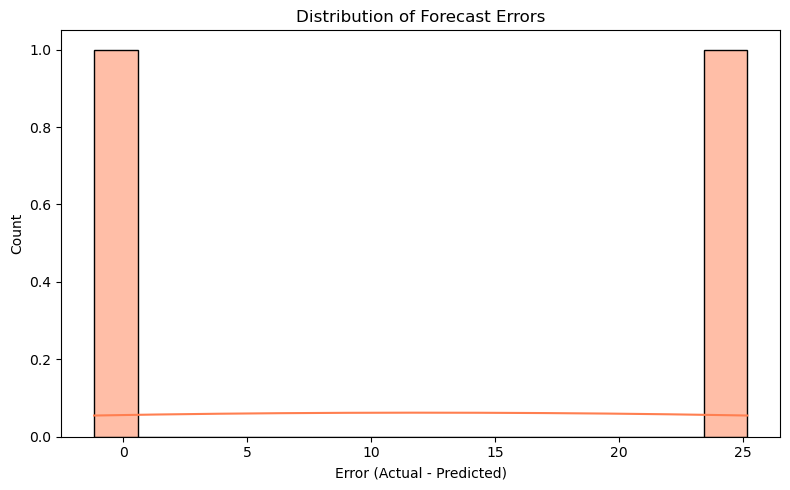

In [47]:
errors = y_test.values - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True, bins=15, color='coral')
plt.title("Distribution of Forecast Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

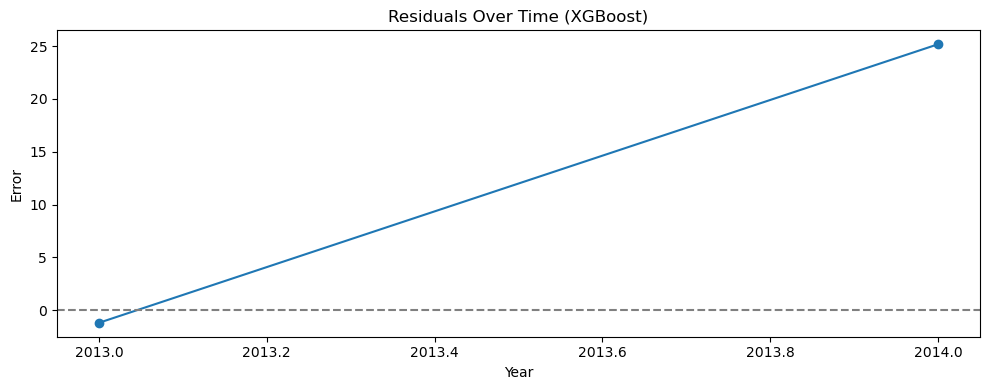

In [48]:
plt.figure(figsize=(10, 4))
plt.plot(test['Year'], errors, marker='o')
plt.axhline(0, linestyle='--', color='gray')
plt.title("Residuals Over Time (XGBoost)")
plt.xlabel("Year")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

In [77]:
results_df = test[['Year']].copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = y_pred
results_df['Error'] = results_df['Actual'] - results_df['Predicted']

print(" Forecast Results:")
print(results_df.to_string(index=False))

# Optional: export
results_df.to_csv("xgboost_results_detailed.csv", index=False)

 Forecast Results:
 Year  Actual  Predicted     Error
 2013       4   5.186966 -1.186966
 2014      42  16.821857 25.178143


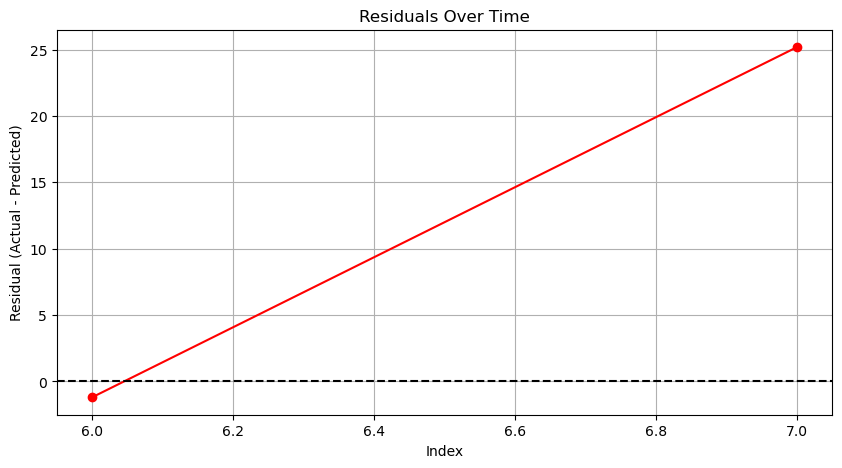

In [49]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.plot(y_test.index, residuals, marker='o', linestyle='-', color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals Over Time')
plt.xlabel('Index')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.show()

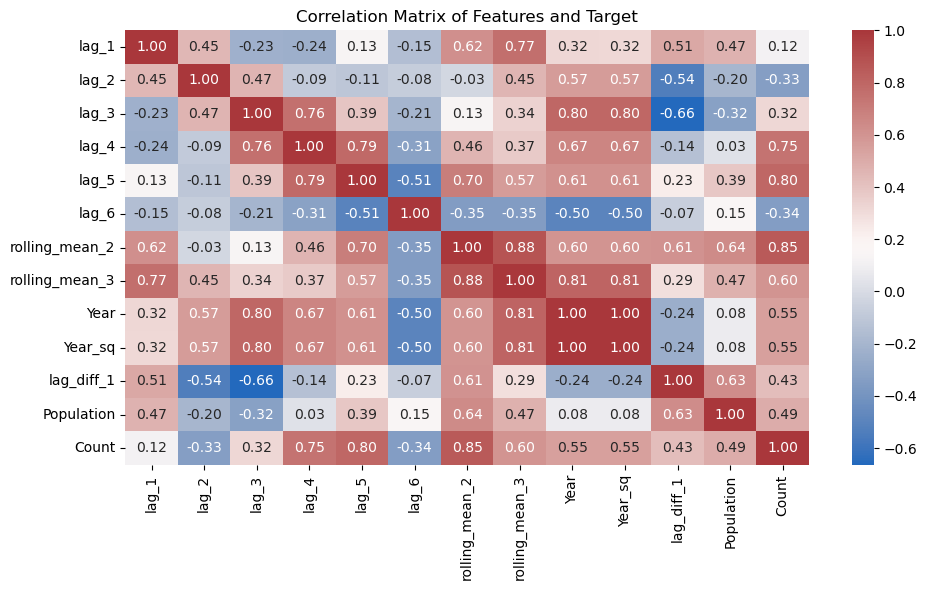

In [50]:
plt.figure(figsize=(10, 6))
corr = ts[features + ['Count']].corr()
sns.heatmap(corr, annot=True, cmap='vlag', fmt=".2f")
plt.title("Correlation Matrix of Features and Target")
plt.tight_layout()
plt.show()

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1}

 Future Forecasts:
   Year   Forecast
0  2015  21.929810
1  2016  17.383118
2  2017  17.860325
3  2018  17.618950


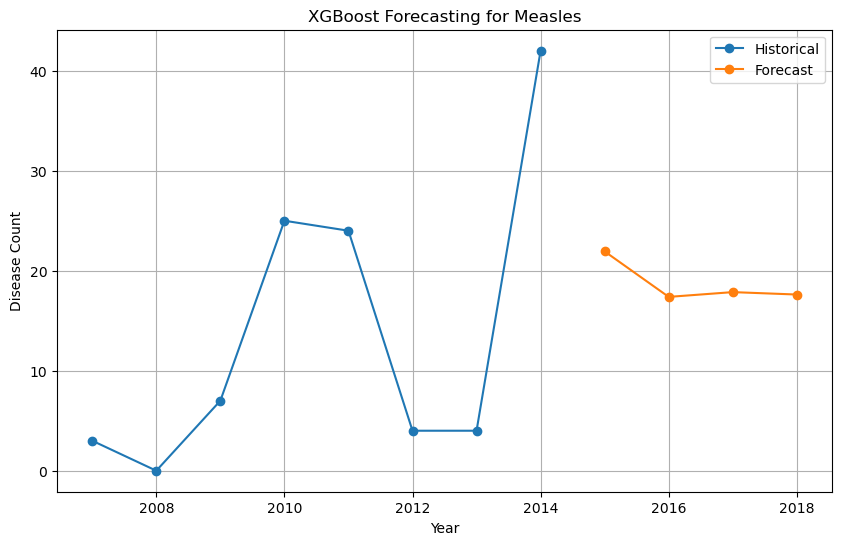

In [51]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


# How many years to forecast
forecast_horizon = 4
last_year = ts['Year'].max()
future_years = list(range(last_year + 1, last_year + 1 + forecast_horizon))

# Store forecasts
future_forecasts = []

# Copy last known row to start forecasting
ts_extended = ts.copy()

for year in future_years:
    last_row = ts_extended.iloc[-1]

    # Build new row
    new_row = {}
    new_row['Year'] = year
    new_row['Year_sq'] = year ** 2
    new_row['Population'] = last_row['Population']  # assume stable

    # Lags
    for i in range(1, 7):
        if i == 1:
            new_row[f'lag_{i}'] = last_row['Count']
        else:
            new_row[f'lag_{i}'] = last_row[f'lag_{i-1}']

    # Rolling means
    rolling_2 = np.mean([new_row['lag_1'], new_row['lag_2']])
    rolling_3 = np.mean([new_row['lag_1'], new_row['lag_2'], new_row['lag_3']])
    new_row['rolling_mean_2'] = rolling_2
    new_row['rolling_mean_3'] = rolling_3

    # Lag difference
    new_row['lag_diff_1'] = new_row['lag_1'] - new_row['lag_2']

    # Predict
    X_new = pd.DataFrame([new_row])[features]
    predicted_count = model.predict(X_new)[0]
    new_row['Count'] = predicted_count
    future_forecasts.append((year, predicted_count))

    # Append to extended data
    ts_extended = pd.concat([ts_extended, pd.DataFrame([new_row])], ignore_index=True)


forecast_df = pd.DataFrame(future_forecasts, columns=['Year', 'Forecast'])
print("\n Future Forecasts:")
print(forecast_df)


plt.figure(figsize=(10, 6))
plt.plot(ts['Year'], ts['Count'], label='Historical', marker='o')
plt.plot(forecast_df['Year'], forecast_df['Forecast'], label='Forecast', marker='o')
plt.xlabel('Year')
plt.ylabel('Disease Count')
plt.title(f'XGBoost Forecasting for {target_disease}')
plt.grid(True)
plt.legend()
plt.show()

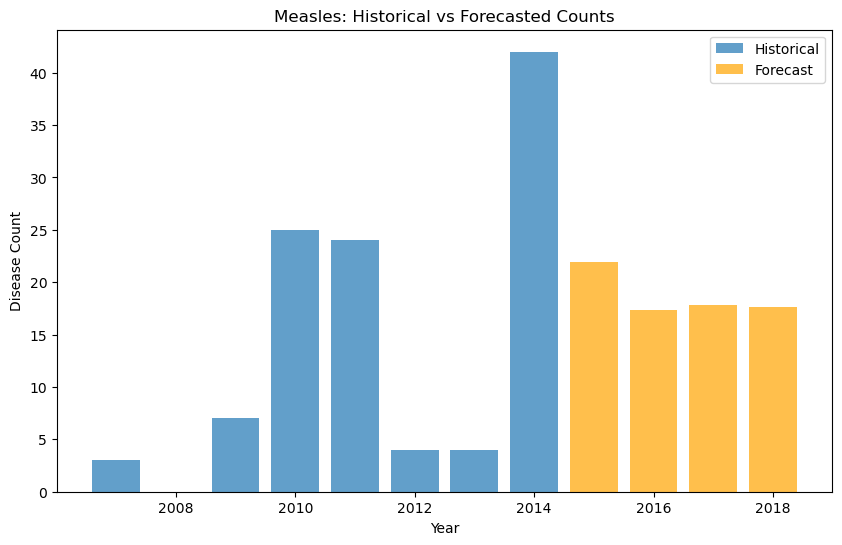

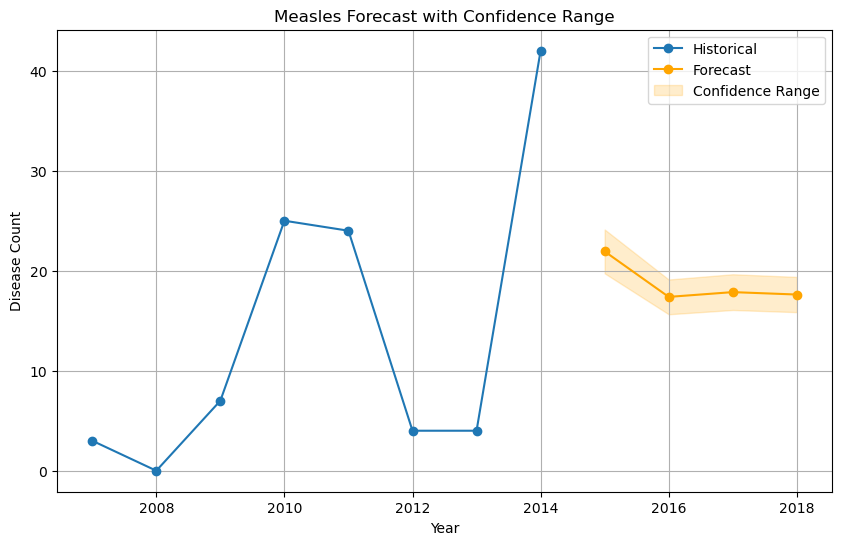

In [52]:
# Combine Historical and Forecast for Analysis
# ------------------------
combined_df = pd.concat([
    ts[['Year', 'Count']].rename(columns={'Count': 'Actual'}),
    forecast_df.rename(columns={'Forecast': 'Actual'})
], ignore_index=True, sort=False)



# 1. Forecast vs Historical (Bar Plot)
plt.figure(figsize=(10, 6))
plt.bar(ts['Year'], ts['Count'], label='Historical', alpha=0.7)
plt.bar(forecast_df['Year'], forecast_df['Forecast'], label='Forecast', alpha=0.7, color='orange')
plt.xlabel('Year')
plt.ylabel('Disease Count')
plt.title(f'{target_disease}: Historical vs Forecasted Counts')
plt.legend()
plt.show()


forecast_df['Lower_CI'] = forecast_df['Forecast'] * 0.9
forecast_df['Upper_CI'] = forecast_df['Forecast'] * 1.1

plt.figure(figsize=(10, 6))
plt.plot(ts['Year'], ts['Count'], label='Historical', marker='o')
plt.plot(forecast_df['Year'], forecast_df['Forecast'], label='Forecast', marker='o', color='orange')
plt.fill_between(forecast_df['Year'], forecast_df['Lower_CI'], forecast_df['Upper_CI'], 
                 color='orange', alpha=0.2, label='Confidence Range')
plt.xlabel('Year')
plt.ylabel('Disease Count')
plt.title(f'{target_disease} Forecast with Confidence Range')
plt.legend()
plt.grid(True)
plt.show()

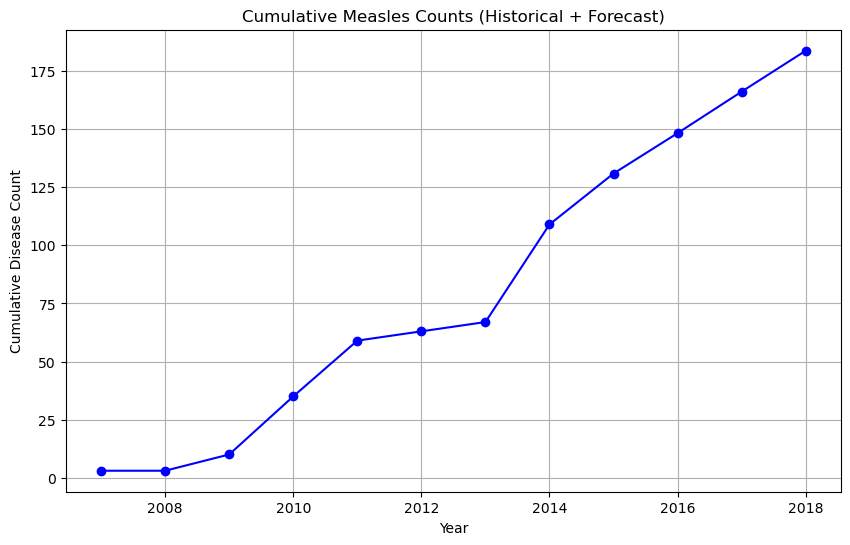

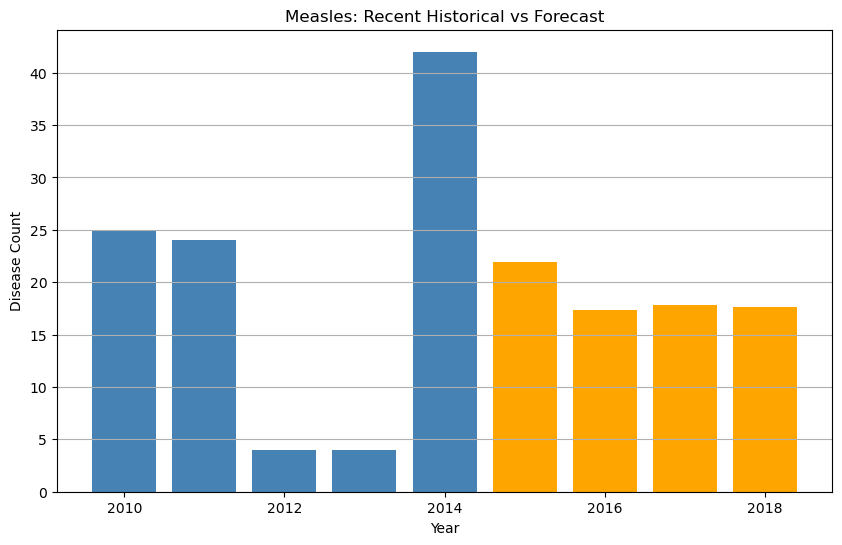

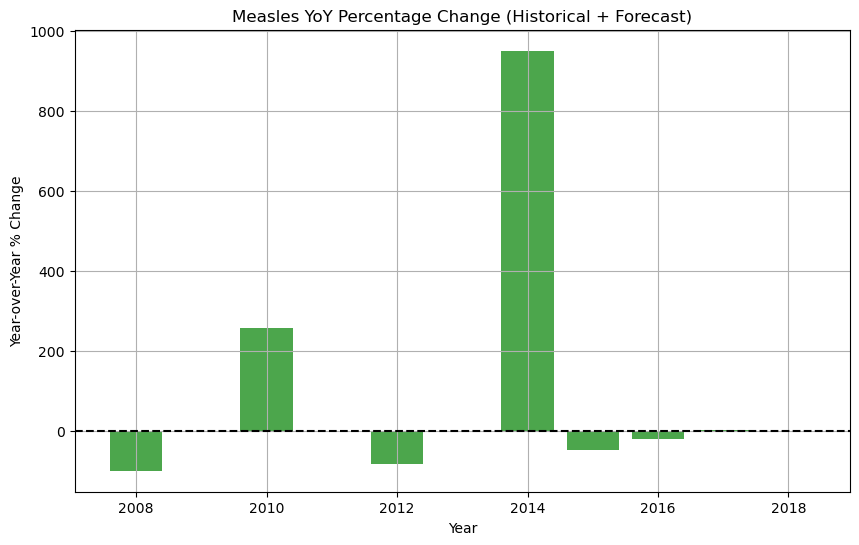

In [53]:
combined_df['Cumulative'] = combined_df['Actual'].cumsum()
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Year'], combined_df['Cumulative'], marker='o', color='blue')
plt.xlabel('Year')
plt.ylabel('Cumulative Disease Count')
plt.title(f'Cumulative {target_disease} Counts (Historical + Forecast)')
plt.grid(True)
plt.show()

recent_df = combined_df[combined_df['Year'] >= combined_df['Year'].max() - 8]
plt.figure(figsize=(10, 6))
plt.bar(recent_df['Year'], recent_df['Actual'], color=['steelblue' if y <= ts['Year'].max() else 'orange' for y in recent_df['Year']])
plt.xlabel('Year')
plt.ylabel('Disease Count')
plt.title(f'{target_disease}: Recent Historical vs Forecast')
plt.grid(axis='y')
plt.show()


combined_df['YoY_Change'] = combined_df['Actual'].pct_change() * 100
plt.figure(figsize=(10, 6))
plt.bar(combined_df['Year'], combined_df['YoY_Change'], color='green', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Year-over-Year % Change')
plt.title(f'{target_disease} YoY Percentage Change (Historical + Forecast)')
plt.grid(True)
plt.show()